In [2]:
%load_ext autoreload
%autoreload 2

In [4]:
import sys
import os
sys.path.append(os.path.abspath('../../'))

In [5]:
from common.preprocessing_util import PreprocessingUtil

X_all, Y_all = PreprocessingUtil.extract_features_resnet_cnn() #use the default value for the batch size 

data transformation is starting...
Starting train_set extraction... this will take a few minutes!
Starting test_set extraction... this will take a few minutes!
Combining extracted features into a single dataset...
Extraction Complete! Final X shape: (70000, 512)


In [6]:
X_train, Y_train, X_val, Y_val, X_test, Y_test = PreprocessingUtil.train_validate_test_split(
    X=X_all, 
    Y=Y_all, 
    train_size=0.70,  # 70% for Training
    val_size=0.15,    # 15% for Validation (Hyperparameter tuning)
    test_size=0.15    # 15% for Final Testing
)

print(f"X_train shape: {X_train.shape}") 
print(f"X_val shape: {X_val.shape}")     
print(f"X_test shape: {X_test.shape}")   

X_train shape: (49000, 512)
X_val shape: (10500, 512)
X_test shape: (10500, 512)


In [ ]:
from sklearn.metrics import accuracy_score
from naive_bayes import custom_naive_bayes

# 1. Initialize your custom model
print("Initializing Custom Gaussian Naive Bayes...")
nb_model = custom_naive_bayes()

# 2. Train the model directly on your extracted CNN variables!
print("Training model with the 512 CNN features...")
nb_model.train(X_train, Y_train) 

# 3. Predict on the unseen Test set
print("Predicting on test set... (this might take a few seconds)")
predictions = nb_model.predict(X_test)


Initializing Custom Gaussian Naive Bayes...
Training model with the 512 CNN features...
Predicting on test set... (this might take a few seconds)

🎉 Final Test Accuracy: 88.43% 🎉


In [9]:
from common.metrices import Metrics
acc = Metrics.accuracy(Y_test, predictions)
precision, recall, f1 = Metrics.evaluate_all(Y_test, predictions)

print(f"Overall Accuracy: {acc * 100:.2f}%")
print(f"Macro Precision: {precision*100:.4f}")
print(f"Macro Recall: {recall*100:.4f}")
print(f"Macro F1-Score: {f1*100:.4f}")

Overall Accuracy: 88.43%
Macro Precision: 88.4216
Macro Recall: 88.3298
Macro F1-Score: 88.3323


In [18]:
import pandas as pd
# This will automatically name the columns 0, 1, 2... up to 511
cnn_df = pd.DataFrame(X_all)

cnn_df['class'] = Y_all #backward compatability as teh function already looks for it 
#because the splitting function takes the top 80% for training directly so i need to shuffle the stacked images from the cnn before passing it 
cnn_df = cnn_df.sample(frac=1, random_state=42).reset_index(drop=True)
X_train_2, Y_train_2, X_test_2, Y_test_2 = PreprocessingUtil.train_test_split(cnn_df, test_size=0.2)

print(f"X_train shape: {X_train_2.shape}")
print(f"Y_train shape: {Y_train_2.shape}")

X_train shape: (56000, 512)
Y_train shape: (56000,)


In [24]:
print("Initializing Custom Gaussian Naive Bayes...")
nb_model_2 = custom_naive_bayes()
# Convert DataFrames to NumPy during training
nb_model_2.train(X_train_2.to_numpy(), Y_train_2.to_numpy())

# Convert DataFrame to NumPy during prediction
predictions_2 = nb_model_2.predict(X_test_2.to_numpy())

# Evaluate passing Y_test as NumPy just to be perfectly safe)
acc_2 = Metrics.accuracy(Y_test_2.to_numpy(), predictions_2)
precision_2, recall_2, f1_2 = Metrics.evaluate_all(Y_test_2.to_numpy(), predictions_2)

print(f"Overall Accuracy: {acc_2 * 100:.2f}%")
print(f"Macro Precision: {precision_2*100:.4f}%")
print(f"Macro Recall: {recall_2*100:.4f}%")
print(f"Macro F1-Score: {f1_2*100:.4f}%")

Initializing Custom Gaussian Naive Bayes...
Overall Accuracy: 88.21%
Macro Precision: 88.1907%
Macro Recall: 88.1101%
Macro F1-Score: 88.1026%


In [33]:
from sklearn.decomposition import PCA

pca = PCA(n_components=150)
X_train_pca = pca.fit_transform(X_train_2)
X_test_pca = pca.transform(X_test_2)

In [34]:
print("Initializing Custom Gaussian Naive Bayes...")
nb_model_3 = custom_naive_bayes()
# Convert DataFrames to NumPy during training
nb_model_3.train(X_train_pca, Y_train_2.to_numpy())

# Convert DataFrame to NumPy during prediction
predictions_3 = nb_model_3.predict(X_test_pca)

# Evaluate passing Y_test as NumPy just to be perfectly safe)
acc_3 = Metrics.accuracy(Y_test_2.to_numpy(), predictions_3)
precision_3, recall_3, f1_3 = Metrics.evaluate_all(Y_test_2.to_numpy(), predictions_3)

print(f"Overall Accuracy: {acc_3 * 100:.2f}%")
print(f"Avg Precision: {precision_3*100:.4f}%")
print(f"Avg Recall: {recall_3*100:.4f}%")
print(f"Avg F1-Score: {f1_3*100:.4f}%")

Initializing Custom Gaussian Naive Bayes...
Overall Accuracy: 88.48%
Avg Precision: 89.5444%
Avg Recall: 88.4676%
Avg F1-Score: 88.6861%


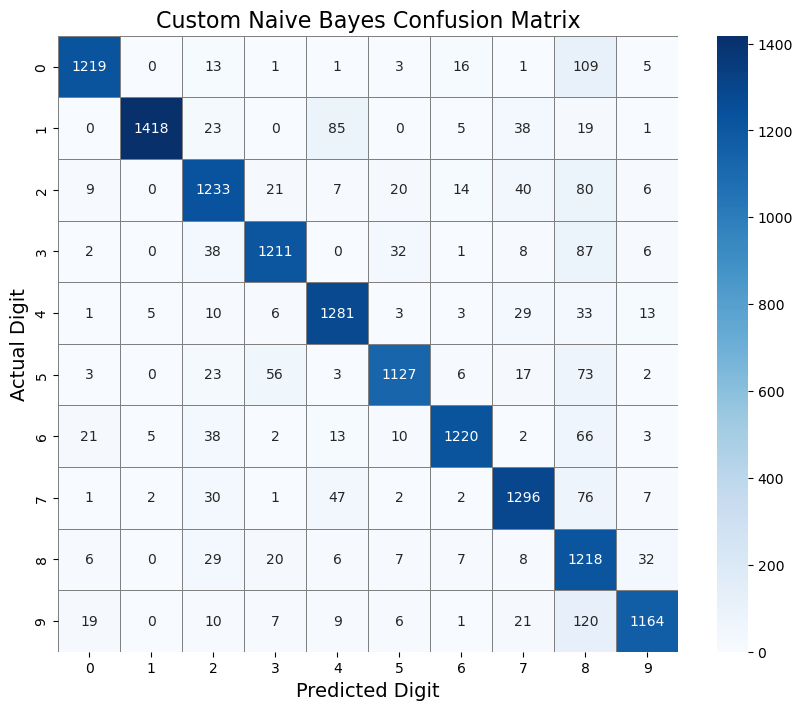

In [44]:
# i should add the confusion matrix plot here
import seaborn as sns
my_cm = Metrics.confusion_matrix(Y_test_2.to_numpy(), predictions_3)

plt.figure(figsize=(10, 8))

# annot=True puts the numbers in the boxes, fmt='d' ensures they are integers
sns.heatmap(my_cm, annot=True, fmt='d', cmap='Blues', 
            cbar=True, linewidths=0.5, linecolor='gray')

# 4. Add labels to make it look professional for your report
plt.title('Custom Naive Bayes Confusion Matrix', fontsize=16)
plt.xlabel('Predicted Digit', fontsize=14)
plt.ylabel('Actual Digit', fontsize=14)
plt.show()

Generating Learning Curves...

Data Size:  10% ( 5600 samples) | Train Acc: 89.14% | Val Acc: 87.62%
Data Size:  20% (11200 samples) | Train Acc: 88.84% | Val Acc: 88.03%
Data Size:  30% (16800 samples) | Train Acc: 88.96% | Val Acc: 88.50%
Data Size:  40% (22400 samples) | Train Acc: 88.71% | Val Acc: 88.34%
Data Size:  50% (28000 samples) | Train Acc: 88.49% | Val Acc: 88.29%
Data Size:  60% (33600 samples) | Train Acc: 88.49% | Val Acc: 88.37%
Data Size:  70% (39200 samples) | Train Acc: 88.46% | Val Acc: 88.44%
Data Size:  80% (44800 samples) | Train Acc: 88.49% | Val Acc: 88.49%
Data Size:  90% (50400 samples) | Train Acc: 88.59% | Val Acc: 88.52%
Data Size: 100% (56000 samples) | Train Acc: 88.49% | Val Acc: 88.48%


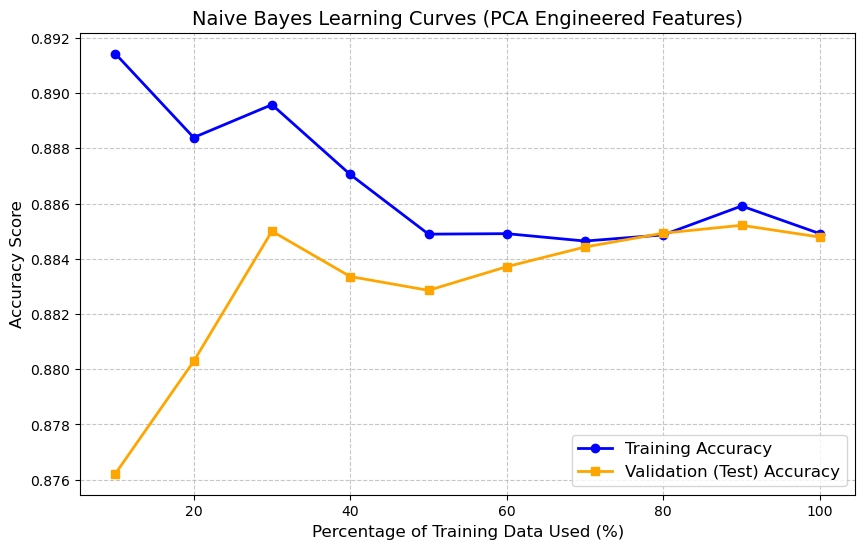

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Define the chunk sizes: 10%, 20%, 30%... up to 100% of the data
train_sizes = np.linspace(0.1, 1.0, 10) 
total_samples = len(X_train_pca)

train_scores = []
val_scores = []

print("Generating Learning Curves...\n")

for size in train_sizes:
    #Calculate how many rows of data to use for this step
    current_size = int(size * total_samples)
    
    # Slice the training data to only include that subset
    X_subset = X_train_pca[:current_size]
    Y_subset = Y_train_2[:current_size]
    
    # initialize a new instace custom model so it doesnt conflict with old models
    model = custom_naive_bayes()
    #train the model on just the subset
    model.train(X_subset, Y_subset)
    
    # evaluate on the Training Subset 
    train_preds = model.predict(X_subset)
    train_acc = Metrics.accuracy(Y_subset, train_preds)
    train_scores.append(train_acc)
    
    # Evaluate on the FULL unseen Test Set (How well did it generalize?)
    val_preds = model.predict(X_test_pca)
    val_acc = Metrics.accuracy(Y_test_2, val_preds)
    val_scores.append(val_acc)
    
    print(f"Data Size: {size*100:3.0f}% ({current_size:5d} samples) | Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}%")

plt.figure(figsize=(10, 6))
plt.plot(train_sizes * 100, train_scores, label="Training Accuracy", marker='o', color='blue', linewidth=2)
plt.plot(train_sizes * 100, val_scores, label="Validation (Test) Accuracy", marker='s', color='orange', linewidth=2)

plt.title("Naive Bayes Learning Curves (PCA Engineered Features)", fontsize=14)
plt.xlabel("Percentage of Training Data Used (%)", fontsize=12)
plt.ylabel("Accuracy Score", fontsize=12)
plt.legend(loc="lower right", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)

# Show the plot
plt.show()